## Some common abbreviations we'll be using
 - GS: Group Stage
 - KO: Knockout Stage
 - LB: Leaderboard
 - XG: Expected Goals

## Imports and Loading Data

In [44]:
from enum import Enum
from copy import copy, deepcopy
from collections.abc import Callable
from concurrent.futures import ThreadPoolExecutor
from collections import defaultdict
from timeit import default_timer as timer
from tqdm.notebook import tqdm

import pandas as pd
import numpy as np
import math

In [2]:
import json
def load_json(path):
  with open(path) as f:
    obj = json.load(f)
    return obj

def load_str(path):
  with open(path) as f:
    res = f.read()
    return res

In [3]:
static_reference = {}

# A DataFrame representing the group stage leaderboard
static_reference['group_stage_leaderboard'] = pd.read_csv(
    "resources/data/group_stage_leaderboard.csv",
    index_col=0
)

# A list of all group stage matches
static_reference['group_stage_matches'] = load_json(
    "resources/data/group_stage_matches.json"
)

# A list of all knockout stage matches (dependant on group stage outcomes)
static_reference['knockout_stage_matches'] = load_str(
    "resources/data/knockout_stage_matches.txt"
)

# All participating teams
static_reference['teams'] = eval(load_str("resources/data/teams.txt"))

# A list of all the groups and the teams in that group
static_reference['groups'] = load_json("resources/data/groups.json")

# FIFA rankings as of May 2026
static_reference['rankings'] = pd.read_csv(
    "resources/data/fifa_rankings.csv", index_col=0
)

# Only the top 8 3rd-placeed teams in the group stage advance, and their
# matchup for the round of 32 are determined by this look-up table
static_reference['outcomes_3rd'] = load_json(
    "resources/data/3rd_place_outcomes.json"
)

# Country name codes (for flag images)
static_reference['team_codes'] = load_json("resources/data/team_codes.json")

# All matches
static_reference['matches'] = load_str("resources/data/matches.json")

# Random number generator of choice
random = np.random.default_rng()

# Lookup table of team names to Team objects
static_teams = {
    name: Team(name) for name in static_reference['teams']
}

In [4]:
static_reference["group_stage_leaderboard"]

,group,points,gd,gf,rank
Mexico,A,0,0,0,-15.0
South Africa,A,0,0,0,-60.0
South Korea,A,0,0,0,-25.0
Czech Republic,A,0,0,0,-41.0
Canada,B,0,0,0,-30.0
Bosnia and Herzegovina,B,0,0,0,-65.0
Qatar,B,0,0,0,-55.0
Switzerland,B,0,0,0,-19.0
Brazil,C,0,0,0,-6.0
Morocco,C,0,0,0,-8.0


In [75]:
class UnknownTeam:
    class Type(Enum):
        pass
class Tournament:
    pass
class Team:
    pass
class Match:
    pass
class TournamentSimulator:
    pass

class Team:
    def __init__(self, name: str):
        self.name = name
        self.ranking_points = ...
        # ...

    def get_features(self):
        return {
            "ranking_points": static_reference["rankings"].loc[self.name, "points"]
        }

class UnknownTeam:
    class Type(Enum):
        GS_PLACEMENT = 1
        KO_ROUND_WINNER = 2
        KO_ROUND_LOSER = 3

    def __init__(self, type: UnknownTeam.Type, team: str | int,
                 tournament: Tournament):
        self.type = type
        self.team = team
        self.tournament = tournament

    def ro32(team: str | int, tournament: Tournament) -> UnknownTeam:
        return UnknownTeam(UnknownTeam.Type.GS_PLACEMENT, team, tournament)

    def ko_winner(team: str | int, tournament: Tournament) -> UnknownTeam:
        return UnknownTeam(UnknownTeam.Type.KO_ROUND_WINNER, team, tournament)

    def ko_loser(team: str | int, tournament: Tournament) -> UnknownTeam:
        return UnknownTeam(UnknownTeam.Type.KO_ROUND_LOSER, team, tournament)

    def identify(self) -> Team:
        group_to_3rd_place_index = {'A':0, 'B':1, 'D':2, 'E':3,
                                'G':4, 'I':5, 'K':6, 'L':7}
        if self.type == UnknownTeam.Type.GS_PLACEMENT:
            if self.team[0] == '3':
                opponent_group = self.team[1:2]
                opponent = group_to_3rd_place_index[opponent_group]
                self.team = static_reference['outcomes_3rd'][self.tournament.top_8_third_places][opponent]
            group = self.team[1:2]
            place = int(self.team[0])
            name = self.tournament.gs_group_lb.loc[group].index[place - 1]
            return self.tournament.teams[name]

        elif self.type == UnknownTeam.Type.KO_ROUND_WINNER:
            return self.tournament.matches[self.team].winner

        elif self.type == UnknownTeam.Type.KO_ROUND_LOSER:
            return self.tournament.matches[self.team].loser

        else:
            raise ValueError("Bad unknown team type: ", self.type)

class Match:
    def __init__(self, home: Team | UnknownTeam, away: Team | UnknownTeam):
        self.home = home
        self.away = away
        self.winner = None
        self.loser = None
        self.home_score = None
        self.away_score = None

    def __repr__(self):
        if isinstance(self.winner, str):
            winner = self.winner
        else:
            winner = self.winner.name
        return f"{self.home.name} ({self.home_score}) vs " \
            f"{self.away.name} ({self.away_score})"

    def simulate(self,
                 xg_predictor: Callable[[dict, dict], tuple[float, float]],
                 goal_simulator: Callable[[float, float], tuple[int, int]],
                 penalty_simulator: Callable[[dict, tuple[float, float]], str],
                 knockout=False):
        if isinstance(self.home, UnknownTeam):
            self.home = self.home.identify()
        if isinstance(self.away, UnknownTeam):
            self.away = self.away.identify()

        home_features = self.home.get_features()
        away_features = self.away.get_features()
        home_xg, away_xg = xg_predictor(home_features, away_features)
        home_score, away_score = goal_simulator(home_xg, away_xg)
        self.home_score, self.away_score = goal_simulator(home_xg, away_xg)

        if self.home_score > self.away_score:
            self.winner, self.loser = self.home, self.away
        elif self.home_score < self.away_score:
            self.winner, self.loser = self.away, self.home
        else:
            if knockout:
                # TODO: overtime with xg/3 ?
                winner = penalty_simulator(
                    home_features, away_features,
                    home_xg, away_xg
                )
                if winner == 'home':
                    self.winner, self.loser = self.home, self.away
                else:
                    self.winner, self.loser = self.away, self.home
            else:
                self.winner = self.loser = 'draw'
        return

class Tournament:
    def __init__(self, teams: dict, gs_lb: pd.DataFrame, matches: str):
        self.teams = deepcopy(teams)
        self.gs_lb = gs_lb.copy()
        self.gs_group_lb = None
        self.matches = eval(matches)
        self.top_8_third_places = None
        self.results = {} # team: (placement, group stage stats)

    def gs_match(self, home, away):
        return Match(self.teams[home], self.teams[away])

    def ro32_match(self, home, away):
        return Match(UnknownTeam.ro32(home, self),
                     UnknownTeam.ro32(away, self))

    def ko_match(self, home, away):
        return Match(UnknownTeam.ko_winner(home, self),
                     UnknownTeam.ko_winner(away, self))

    def bronze(self, home, away):
        return Match(UnknownTeam.ko_loser(home, self),
                     UnknownTeam.ko_loser(away, self))

    def final(self, home, away):
        return self.ko_match(home, away)

    def simulate(self,
                 xg_predictor: Callable[[dict, dict], tuple[float, float]],
                 goal_simulator: Callable[[float, float], tuple[int, int]],
                 penalty_simulator: Callable[[dict, tuple[float, float]], str]):
        simulators = (xg_predictor, goal_simulator, penalty_simulator)
        for i in range (1, 105):
            match = self.matches[i]
            match.simulate(*simulators, knockout=(i > 72))
            if i <= 72:
                self._update_gs_lb(match)
            if i == 72:
                self._create_gs_group_lb()
            self._update_results(match, i)

    def _update_gs_lb(self, match: Match):
        if match.winner == 'draw':
            self.gs_lb.loc[match.home.name, 'points'] += 1
            self.gs_lb.loc[match.away.name, 'points'] += 1
        elif match.winner is match.home:
            self.gs_lb.loc[match.home.name, 'points'] += 3
        else:
            self.gs_lb.loc[match.away.name, 'points'] += 3
        self.gs_lb.loc[match.home.name, 'gf'] += match.home_score
        self.gs_lb.loc[match.home.name, 'gd'] += match.home_score - match.away_score
        self.gs_lb.loc[match.away.name, 'gf'] += match.away_score
        self.gs_lb.loc[match.away.name, 'gd'] += match.away_score - match.home_score

    def _create_gs_group_lb(self):
        def sort_group(group):
            """FIFA WC'26 Tie-Breakers"""
            return group.sort_values(['points', 'gd', 'gf', 'rank'],
                                     ascending=False)
        self.gs_group_lb = self.gs_lb.groupby('group') \
                                     .apply(sort_group, include_groups=False)
        third_placers = self.gs_group_lb.iloc[2::4]
        qualified = sort_group(third_placers).head(8).index.get_level_values(0)
        self.top_8_third_places = "".join(sorted([g[0] for g in qualified]))

    def _update_results(self, match: Match, index: int):
        if (index := index - 72) <= 0:
            return
        if (index := index - 16) <= 0:
            self.results[match.loser.name] = 32
            return
        if (index := index - 8) <= 0:
            self.results[match.loser.name] = 16
            return
        if (index := index - 4) <= 0:
            self.results[match.loser.name] = 8
            return
        if (index := index - 2) <= 0:
            pass
        if (index := index - 1) <= 0:
            self.results[match.loser.name] = 4
            self.results[match.winner.name] = 3
            return
        if (index := index - 1) <= 0:
            self.results[match.loser.name] = 2
            self.results[match.winner.name] = 1
            for team in self.teams.keys():
                if team not in self.results:
                    self.results[team] = 48
                placement = self.results[team]
                self.results[team] = (placement, self.gs_lb.loc[team])
            return

class TournamentSimulator:
    def __init__(self,
                 num_simulations: int,
                 teams: dict,
                 gs_lb: pd.DataFrame,
                 matches: str,
                 xg_predictor: Callable[[dict, dict], tuple[float, float]],
                 goal_simulator: Callable[[float, float], tuple[int, int]],
                 penalty_simulator: Callable[[dict, tuple[float, float]], str],
                 max_workers=None):
        self.run = False
        self.num = num_simulations
        self.teams = teams
        self.gs_lb = gs_lb
        self.matches = matches
        self.simulators = (xg_predictor, goal_simulator, penalty_simulator)
        self.max_workers = max_workers
        self.all_placements = None
        self.summary = None
        self.avg_gs_lb = None

    def simulate(self):
        n = self.num
        with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
            all_placements = list(tqdm(
                executor.map(self._run_a_simulation, range(n)),
                total=n,
                desc='Simulating'
            ))

        self.summary, self.avg_gs_lb = self._aggregrate(all_placements)

    def _run_a_simulation(self: TournamentSimulator, _) -> dict:
        t = Tournament(self.teams, self.gs_lb, self.matches)
        t.simulate(*self.simulators)
        return t.results

    def _aggregrate(self, all_placements: list[dict]) -> tuple[pd.DataFrame, pd.DataFrame]:
        n = self.num
        counts = defaultdict(lambda: defaultdict(int))
        gs_lb = static_reference['group_stage_leaderboard'].copy().drop(columns=['group'])

        for result in all_placements:
            for team, [place, gs_results] in result.items():
                gs_lb.loc[team] += gs_results
                # print("**********PLACE:", place, "**********")
                # if place < 48:  counts[team]["Group Stage"] += 1
                if place <= 32: counts[team]["Round of 32"] += 1
                if place <= 16: counts[team]["Round of 16"] += 1
                if place <= 8:  counts[team]["Quarter-Finals"] += 1
                if place <= 4:  counts[team]["Semi-Finals"] += 1
                if place <= 2:  counts[team]["Finals"] += 1
                if place == 1:  counts[team]["Win"] += 1

        df = pd.DataFrame.from_dict(counts, orient="index") \
                         .fillna(0).astype(int)
        df = df[["Win", "Finals", "Semi-Finals", "Quarter-Finals",
                 "Round of 16", "Round of 32"]]
        df = df * 100.0 / n
        df = df.sort_values("Win", ascending=False)

        gs_lb = gs_lb / n

        return df, gs_lb

In [120]:
def random_xg(home_features: dict, away_features: dict) -> tuple[float, float]:
    home_xg = 6 * random.random()
    away_xg = 6 * random.random()
    return home_xg, away_xg

def coinflip_pens(*args) -> str:
    n = random.random()
    if n < 0.5:
        return 'home'
    else:
        return 'away'

def goals_is_xg(home_xg: float, away_xg: float) -> tuple[int, int]:
    return int(home_xg), int(away_xg)

def higher_xg_always_wins(home_xg: float, away_xg: float) -> tuple[int, int]:
    if home_xg > away_xg:
        return (1, 0)
    return (0, 1)

def simple_xg_predictor(home_features: dict, away_features: dict) -> tuple[float, float]:
    home_points = home_features["ranking_points"]
    away_points = away_features["ranking_points"]
    total_points = home_points + away_points
    point_diff = home_points - away_points
    home_xg = math.exp(home_points / total_points)
    away_xg = math.exp(away_points / total_points)
    return home_xg, away_xg

def poisson_evaluator(home_xg: float, away_xg: float) -> tuple[int, int]:
    return tuple(random.poisson(lam=[home_xg, away_xg]))

In [121]:
start = timer()
t = Tournament(
    teams=static_teams,
    gs_lb=static_reference['group_stage_leaderboard'],
    matches=static_reference['matches']
)
t.simulate(simple_xg_predictor, higher_xg_always_wins, coinflip)
end = timer()
print(end - start)

0.09226821700576693


In [73]:
start = timer()
s = TournamentSimulator(
    num_simulations   = 1000,
    teams             = static_teams,
    gs_lb             = static_reference['group_stage_leaderboard'],
    matches           = static_reference['matches'],
    xg_predictor      = random_xg,
    goal_simulator    = goals_is_xg,
    penalty_simulator = coinflip
)
s.simulate()
end = timer()
print(end - start)

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/diego/Projects/Coding/World_Cup_2026/.venv/lib/python3.13/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


87.78292615900864


In [79]:
# s.summary
t.matches

{1: Mexico (3) vs South Africa (3),
 2: South Korea (0) vs Czech Republic (1),
 25: Czech Republic (2) vs South Africa (5),
 28: Mexico (0) vs South Korea (0),
 53: Czech Republic (2) vs Mexico (3),
 54: South Africa (5) vs South Korea (3),
 3: Canada (0) vs Bosnia and Herzegovina (4),
 8: Qatar (3) vs Switzerland (3),
 26: Switzerland (5) vs Bosnia and Herzegovina (3),
 27: Canada (4) vs Qatar (3),
 51: Switzerland (3) vs Canada (1),
 52: Bosnia and Herzegovina (4) vs Qatar (0),
 7: Brazil (0) vs Morocco (3),
 5: Haiti (5) vs Scotland (2),
 30: Scotland (1) vs Morocco (2),
 29: Brazil (0) vs Haiti (3),
 49: Scotland (0) vs Brazil (5),
 50: Morocco (0) vs Haiti (5),
 4: United States (0) vs Paraguay (3),
 6: Australia (2) vs Turkey (0),
 32: United States (2) vs Australia (0),
 31: Turkey (5) vs Paraguay (0),
 59: Turkey (2) vs United States (1),
 60: Paraguay (4) vs Australia (3),
 10: Germany (3) vs Curaçao (0),
 9: Ivory Coast (1) vs Ecuador (4),
 33: Germany (0) vs Ivory Coast (2),

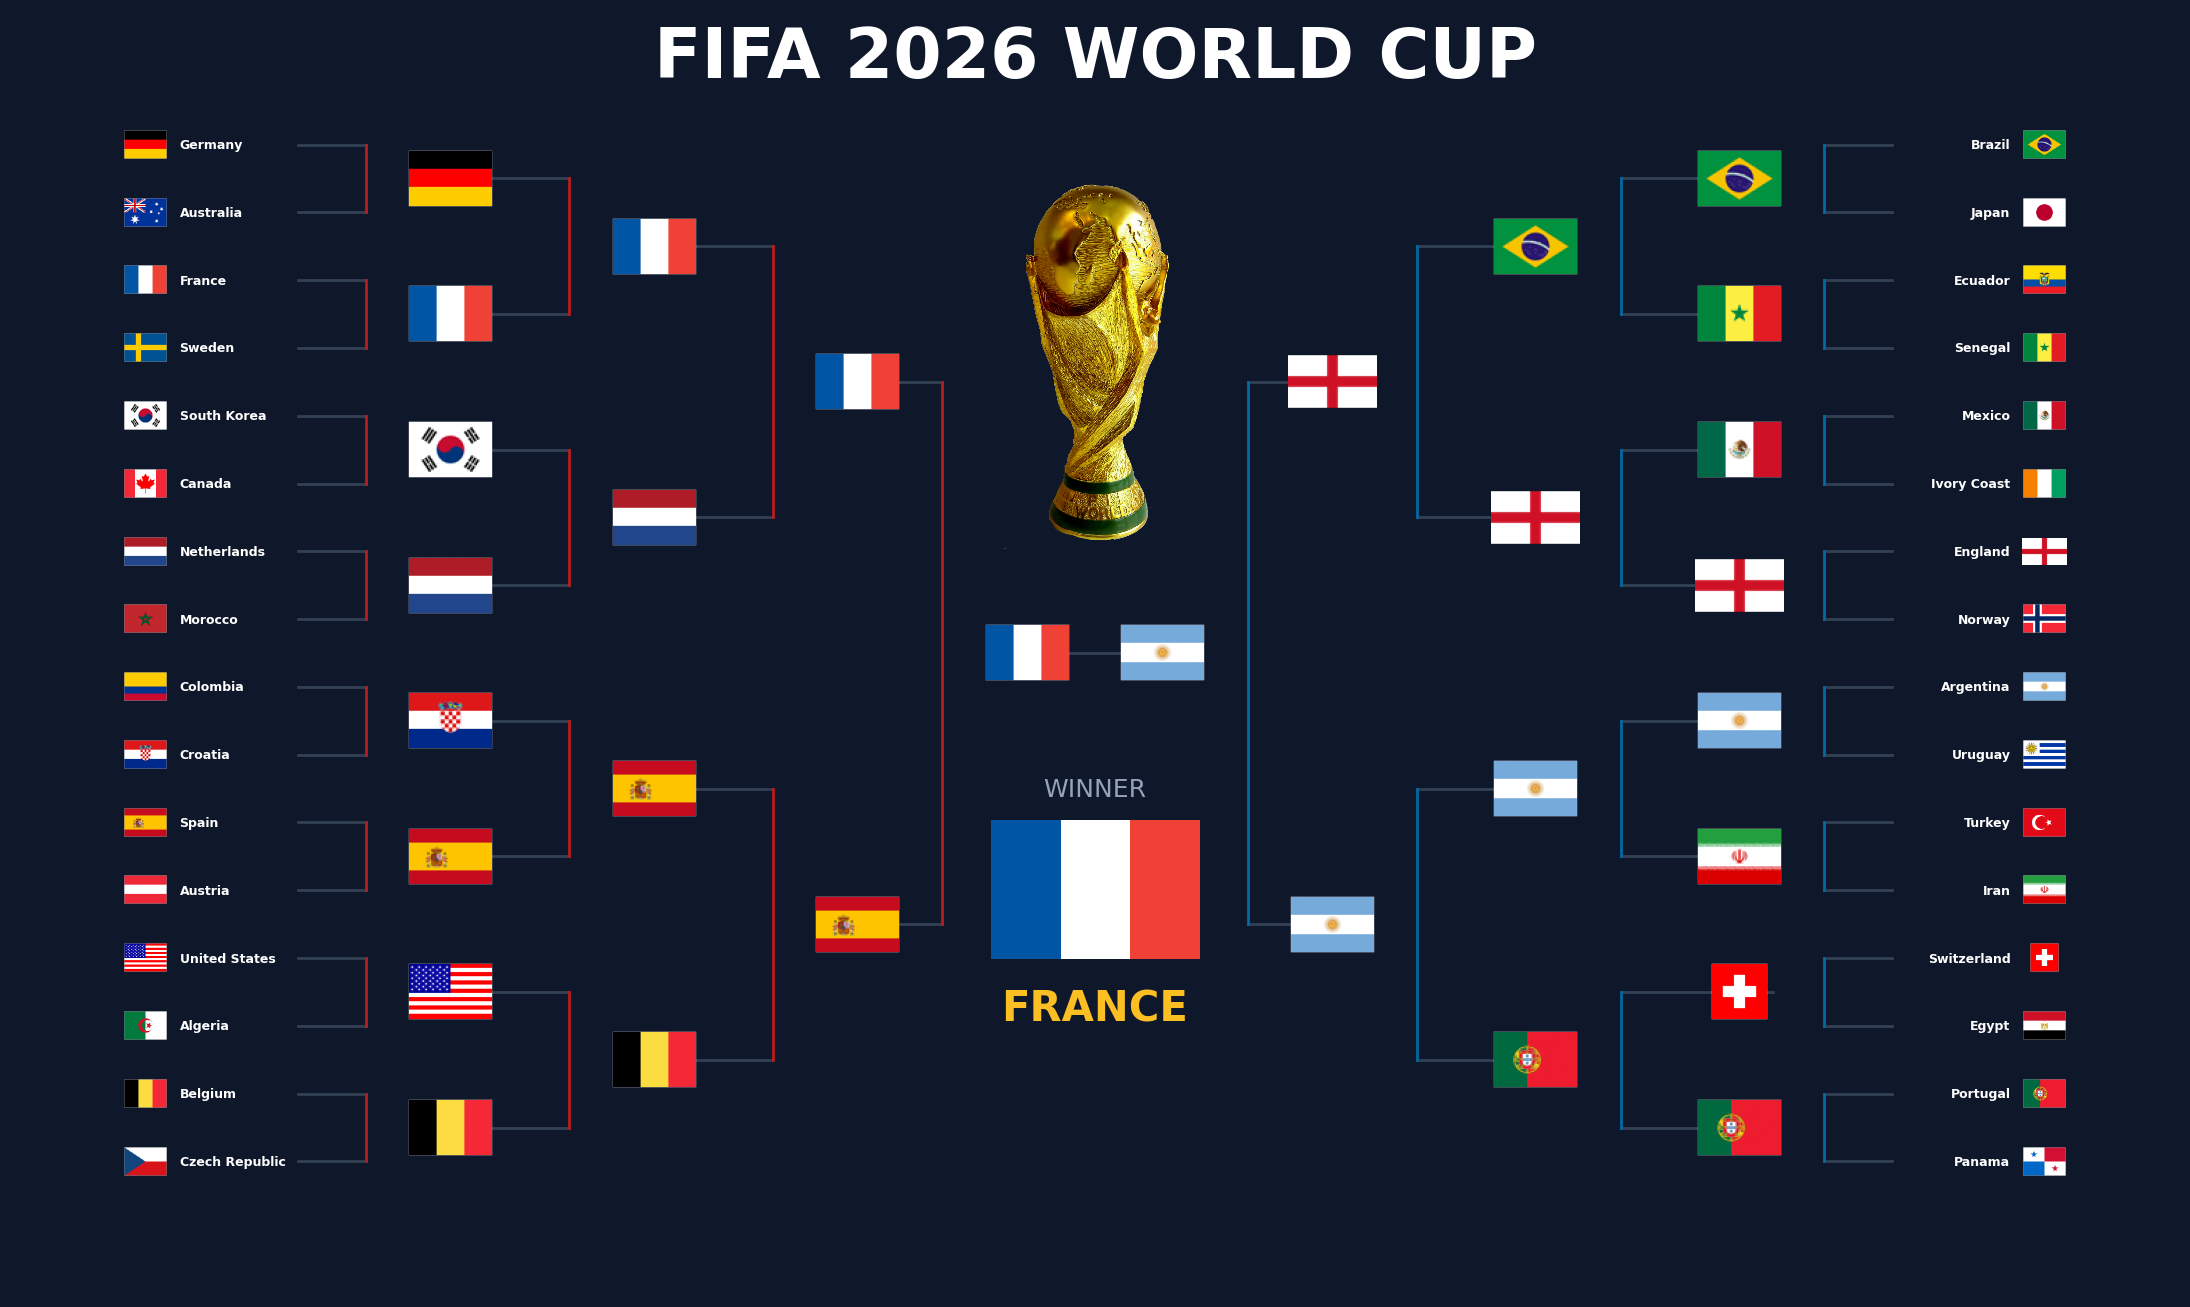

In [177]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import os

# ==========================================
# 1. YOUR CUSTOM FUNCTIONS (Replace these)
# ==========================================

def get_flag_location(team_name):
    """
    Replace this with your actual function.
    Returns the file path to the 64x64 flag image.
    """
    code = static_reference['team_codes'][team_name]
    return f"./resources/flags/{code}.png"

# ==========================================
# 2. TOURNAMENT DATA PARSER
# ==========================================

def parse_tournament_data(matches_dict):
    """
    Takes a dict of 32 knockout matches and structures them for the bracket.
    Assumes match IDs are sequential (e.g., 73-104 or 1-32).
    """
    sorted_ids = list(range(73, 105))
    
    if len(sorted_ids) != 32:
        print(f"Warning: Expected 32 matches for a full 32-team knockout stage, got {len(sorted_ids)}.")

    # Group sequential matches by round
    r32_matches = sorted_ids[0:16]   # 16 matches
    r16_matches = sorted_ids[16:24]  # 8 matches
    qf_matches  = sorted_ids[24:28]  # 4 matches
    sf_matches  = sorted_ids[28:30]  # 2 matches
    third_place_match = sorted_ids[30] # 1 match
    final_match = sorted_ids[31]       # 1 match

    def get_teams(match_ids):
        teams = []
        for m_id in match_ids:
            teams.append(matches_dict[m_id].home.name)
            teams.append(matches_dict[m_id].away.name)
        return teams

    def get_winners(match_ids):
        return [matches_dict[m_id].winner.name for m_id in match_ids]

    # --- Build the Arrays ---
    
    # Round of 32 (Split 16 teams left, 16 teams right)
    all_r32_teams = get_teams(r32_matches)
    r32_left = get_teams([74, 77, 73, 75, 83, 84, 81, 82])
    r32_right = get_teams([76, 78, 79, 80, 86, 88, 85, 87])

    # Round of 16 (Winners of R32)
    all_r16_teams = get_winners(r32_matches)
    r16_left = get_teams([89, 90, 93, 94])
    r16_right = get_teams([91, 92, 95, 96])

    # Quarter-Finals (Winners of R16)
    all_qf_teams = get_winners(r16_matches)
    qf_left = get_teams([97, 98])
    qf_right = get_teams([99, 100])

    # Semi-Finals (Winners of QF)
    all_sf_teams = get_winners(qf_matches)
    sf_left = get_teams([101])
    sf_right = get_teams([102])

    # Finals & Third Place
    final_data = matches_dict[final_match]
    finalists = [final_data.home.name, final_data.away.name]
    champion = final_data.winner.name
    third_place = matches_dict[third_place_match].winner.name

    return r32_left, r32_right, r16_left, r16_right, qf_left, qf_right, sf_left, sf_right, finalists, champion, third_place

# ==========================================
# 3. BRACKET RENDERING ENGINE
# ==========================================

def draw_dynamic_bracket(matches_dict):
    (r32_left, r32_right, r16_left, r16_right, 
     qf_left, qf_right, sf_left, sf_right, 
     finalists, champion, third_place) = parse_tournament_data(matches_dict)

    fig, ax = plt.subplots(figsize=(22, 14))
    fig.patch.set_facecolor('#0f172a')
    ax.set_facecolor('#0f172a')
    ax.axis('off')
    ax.set_xlim(-5, 59)
    ax.set_ylim(-4, 34)

    def add_flag(x, y, team_name, ax, zoom=0.5):
        flag_path = get_flag_location(team_name) 
        if flag_path and os.path.exists(flag_path):
            img = mpimg.imread(flag_path)
            imagebox = OffsetImage(img, zoom=zoom)
            ab = AnnotationBbox(imagebox, (x, y), frameon=False)
            ax.add_artist(ab)
        else:
            ax.plot(x, y, 'ws', markersize=8) 

    def draw_bracket_side(r32, r16, qf, sf, side="left"):
        if side == "left":
            x_cols = [0, 6, 12, 18, 22] 
            direction = 1
            align = 'left'
        else:
            x_cols = [54, 48, 42, 36, 32]
            direction = -1
            align = 'right'

        # line_start dictates the gap left for text. 
        # flag_line_start closes that gap for the flag-only rounds.
        line_start = 3.5 * direction
        flag_line_start = 1.0 * direction 
        line_end = 0.5 * direction
        flag_spacing = 2.0 * direction
        
        y_r32 = list(range(30, -1, -2))
        
        # Draw Round of 32 (Text + Flags)
        for i, team in enumerate(r32):
            ax.text(x_cols[0], y_r32[i], team, color='white', va='center', ha=align, fontsize=9, weight='bold')
            add_flag(x_cols[0] - (1.0 * direction), y_r32[i], team, ax)
            ax.plot([x_cols[0] + line_start, x_cols[1] - line_end], [y_r32[i], y_r32[i]], color='#334155', lw=2)

        # Draw Round of 16 (Flags Only)
        y_r16 = [(y_r32[i] + y_r32[i+1])/2 for i in range(0, 16, 2)]
        for i, team in enumerate(r16):
            add_flag(x_cols[1]+flag_spacing, y_r16[i], team, ax, zoom=1)
            ax.plot([x_cols[1] - line_end, x_cols[1] - line_end], [y_r32[i*2], y_r32[i*2+1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)
            # Notice we use flag_line_start here so the line connects to the flag
            ax.plot([x_cols[1] + flag_line_start, x_cols[2] - line_end], [y_r16[i], y_r16[i]], color='#334155', lw=2)

        # Draw Quarter-Finals (Flags Only)
        y_qf = [(y_r16[i] + y_r16[i+1])/2 for i in range(0, 8, 2)]
        for i, team in enumerate(qf):
            add_flag(x_cols[2]+flag_spacing, y_qf[i], team, ax, zoom=1)
            ax.plot([x_cols[2] - line_end, x_cols[2] - line_end], [y_r16[i*2], y_r16[i*2+1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)
            ax.plot([x_cols[2] + flag_line_start, x_cols[3] - line_end], [y_qf[i], y_qf[i]], color='#334155', lw=2)

        # Draw Semi-Finals (Flags Only)
        y_sf = [(y_qf[i] + y_qf[i+1])/2 for i in range(0, 4, 2)]
        for i, team in enumerate(sf):
            add_flag(x_cols[3]+flag_spacing, y_sf[i], team, ax, zoom=1)
            ax.plot([x_cols[3] - line_end, x_cols[3] - line_end], [y_qf[i*2], y_qf[i*2+1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)
            ax.plot([x_cols[3] + flag_line_start, x_cols[4] + line_end], [y_sf[i], y_sf[i]], color='#334155', lw=2)
            
        # Connect to Finalist
        y_fin = (y_sf[0] + y_sf[1])/2
        ax.plot([x_cols[4] + line_end, x_cols[4] + line_end], [y_sf[0], y_sf[1]], color='#b91c1c' if side=="left" else '#0369a1', lw=2)
        
        return y_fin

    # 5. Render Everything
    y_final_left = draw_bracket_side(r32_left, r16_left, qf_left, sf_left, side="left")
    y_final_right = draw_bracket_side(r32_right, r16_right, qf_right, sf_right, side="right")

    # Center Elements (Flags Only for the finalists)
    ax.plot([25, 29], [y_final_left, y_final_left], color='#334155', lw=2)
    add_flag(25, y_final_left, finalists[0], ax, zoom=1)
    add_flag(29, y_final_right, finalists[1], ax, zoom=1)

    # Trophy
    trophy_path = "./resources/images/trophy.png"
    trophy_img = mpimg.imread(trophy_path)
    trophy_box = OffsetImage(trophy_img, zoom=0.25) 
    trophy_ab = AnnotationBbox(trophy_box, (27, 23.5), frameon=False)
    ax.add_artist(trophy_ab)

    # Winner gets text + flag
    ax.text(27, 11, "WINNER", color='#94a3b8', va='center', ha='center', fontsize=18)
    ax.text(27, 4.5, champion.upper(), color='#fbbf24', va='center', ha='center', fontsize=30, weight='bold')
    add_flag(27, 8, champion, ax, zoom=2.5)
    plt.suptitle("FIFA 2026 WORLD CUP", color='white', fontsize=50, weight='bold', y=0.92)

    plt.tight_layout()
    plt.show()


draw_dynamic_bracket(t.matches)
# parse_tournament_data(t.matches)
# t.matches